# Citi Bike: mistakes and feature checks

**Contribution owner: Tomislav Novosel.** Implementation, experiments and initial explanations were prepared with AI assistance on 9 October 2026. Human review and substantive changes should be recorded when they happen; see [the assistance record](../docs/AI_USE.md).

These are development experiments, not final-test results. The training/tuning dates end in June; July-September is development validation. October-December has not been scored.

The searches were executed with the helper scripts and their actual reports are saved. By default this notebook reviews those reports quickly. Set `CITIBIKE_RETRAIN=1` or use the runner's `--train` option to execute the search again. The XGBoost search needs a CUDA GPU; viewing results and running the saved app do not.


We inspect the chosen candidate on development validation. These diagnostics can guide selection, so they are not a fresh independent test.

In [14]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
while not (ROOT / 'src/citibike_forecast.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open the notebook inside the repository.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import numpy as np
from citibike_forecast import REPORTS, MODELS, development_data, chronological_cv
RUN_TRAINING = os.environ.get('CITIBIKE_RETRAIN') == '1'
def report(name):
    return json.loads((REPORTS / (name + '_run.json')).read_text(encoding='utf8'))
print('Mode:', 'execute training' if RUN_TRAINING else 'review actual saved experiments')
from citibike_forecast import run_errors
if RUN_TRAINING:
    run_errors()
display(pd.read_csv(REPORTS / 'largest_errors.csv'))
display(pd.read_csv(REPORTS / 'error_groups.csv'))


Mode: review actual saved experiments


,date,actual,predicted,error,absolute_error,weekday,month
0,2023-09-23,36069,142278.484375,106209.484375,106209.484375,Saturday,9
1,2023-09-29,49184,129203.898438,80019.898438,80019.898438,Friday,9
2,2023-09-24,34864,105714.636719,70850.636719,70850.636719,Sunday,9
3,2023-09-18,59963,121170.908203,61207.908203,61207.908203,Monday,9
4,2023-09-26,84023,134273.128906,50250.128906,50250.128906,Tuesday,9
5,2023-08-10,90453,138083.343262,47630.343262,47630.343262,Thursday,8
6,2023-09-28,107534,148344.298340,40810.298340,40810.298340,Thursday,9
7,2023-07-16,65329,103116.674805,37787.674805,37787.674805,Sunday,7
8,2023-09-30,103003,65629.960938,-37373.039062,37373.039062,Saturday,9
9,2023-07-09,88395,124734.554688,36339.554688,36339.554688,Sunday,7


,group,value,mae,rmse,wape,bias,days
0,weekday,Friday,14889.735089,25105.584242,0.123521,6757.263916,13
1,weekday,Monday,14613.045063,21504.588876,0.136120,4846.232337,13
2,weekday,Saturday,18122.566982,31963.931044,0.152870,-2522.870449,14
3,weekday,Sunday,20298.049110,28004.707134,0.197902,14474.140231,13
4,weekday,Thursday,13635.927274,20488.408755,0.105009,7794.037213,13
5,weekday,Tuesday,16010.796913,20668.631436,0.125712,-183.007024,13
6,weekday,Wednesday,5014.606088,7715.788095,0.036303,-4336.852182,13
7,month,7,12236.512219,15634.783156,0.103660,505.152513,31
8,month,8,10253.785857,15224.122435,0.080184,-495.759584,31
9,month,9,21817.492379,34509.126673,0.188534,11532.074044,30


Keep the selected XGBoost configuration fixed and compare compact with full features on the same dates. The full set lowers MAE from about 16,852 to 14,693; this is an ablation of a group of features, not proof about each individual feature.

In [15]:
display(pd.read_csv(REPORTS / 'feature_ablation.csv'))
print('The worst miss is 23 September: 142,278 predicted versus 36,069 recorded. The cause is not established by these counts.')
print('Calendar and past rides cannot anticipate every unusual drop. Weather forecasts or known events would be future extensions, if their availability before prediction can be verified.')


The worst miss is 23 September: 142,278 predicted versus 36,069 recorded. The cause is not established by these counts.
Calendar and past rides cannot anticipate every unusual drop. Weather forecasts or known events would be future extensions, if their availability before prediction can be verified.


,feature_set,mae,rmse,wape,bias,days,cv_mean_mae
0,compact,16851.851236,24417.057582,0.139733,-389.948797,92,15397.920286
1,full,14692.652301,23426.393863,0.121829,3763.623936,92,14058.179381


Predictions above the diagonal overestimate rides. Large errors remain even when the average error improves.

No event loop hook running.


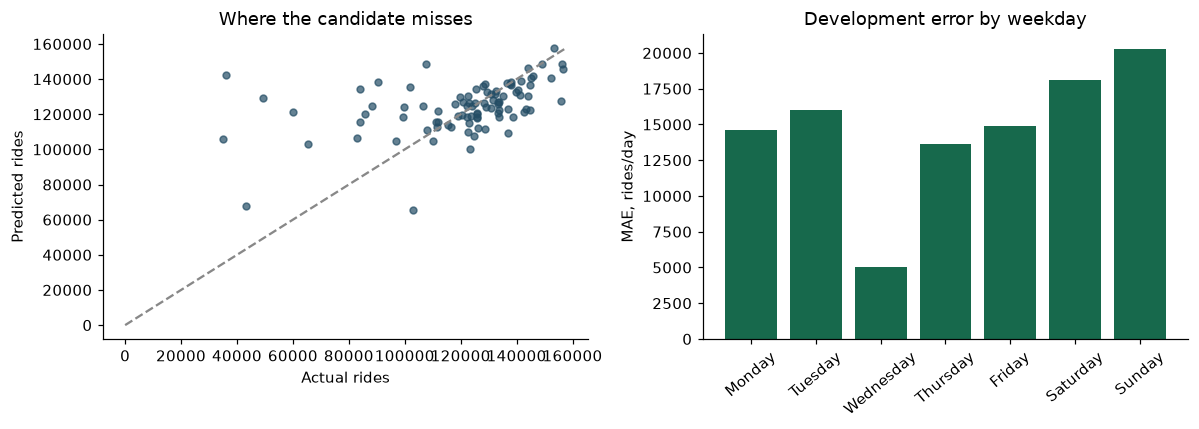

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
FIGURES = ROOT / 'citibike/figures'
pred = pd.read_csv(REPORTS / 'xgboost_tuned_validation.csv')
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(pred.actual, pred.predicted, color='#244d65', s=20, alpha=.7)
limit = max(pred.actual.max(),pred.predicted.max())
axes[0].plot([0,limit],[0,limit],color='#888',linestyle='--')
axes[0].set(xlabel='Actual rides',ylabel='Predicted rides',title='Where the candidate misses')
groups = pd.read_csv(REPORTS / 'error_groups.csv')
weekdays = groups[groups.group.eq('weekday')].set_index('value').reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[1].bar(weekdays.index,weekdays.mae,color='#17694c'); axes[1].tick_params(axis='x',rotation=40)
axes[1].set(ylabel='MAE, rides/day',title='Development error by weekday')
fig.tight_layout(); fig.savefig(FIGURES / 'forecast_errors.png',dpi=150); plt.show()
